<div align="center" style="font-size: 2.5em; font-weight: bold; margin-bottom: 10px;">ChatGTP</div>
<div align="center" style="font-size: 1.8em; font-weight: bold; margin-bottom: 15px;">Gdje to piše (DzeToPishe)</div>
<div align="center" style="font-size: 1.3em; margin-bottom: 25px;">Diplomski rad</div>
<div align="right" style="font-style: italic; color: #666;">by Zlatko Pračić</div>

## 1. Postavljanje okruženja

Ovaj dio notebooka instalira sve potrebne biblioteke, montira Google Drive i konfigurira pristup Hugging Face platformi.

### Instalacija potrebnih biblioteka

Instaliramo sve Python biblioteke potrebne za rad:
- **bitsandbytes** - kvantizacija modela za uštedu memorije
- **transformers, torch, accelerate** - rad s LLM modelima
- **sentence-transformers, faiss-cpu** - vektorizacija teksta i pretraživanje sličnosti
- **python-docx, pdfplumber** - ekstrakcija teksta iz dokumenata

In [ ]:
!pip install -U bitsandbytes
!pip install transformers torch accelerate sentencepiece
!pip install -U sentence-transformers faiss-cpu
!pip install python-docx pdfplumber

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 102.1 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.4.0
    Uninstalling sentence-transformers-5.4.0:
      Successfully uninstalled sentence-transformers-5.4.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 131.0 MB/s eta 0:00:00


---

**bitsandbytes**
https://huggingface.co/docs/transformers/en/quantization/bitsandbytes
https://pypi.org/project/bitsandbytes/

**transformers**
https://huggingface.co/docs/transformers/index
https://pypi.org/project/transformers/

**torch (PyTorch)**
https://pytorch.org/docs/stable/index.html
https://pypi.org/project/torch/

**accelerate**
https://huggingface.co/docs/accelerate/index
https://pypi.org/project/accelerate/

**sentencepiece**
https://github.com/google/sentencepiece
https://pypi.org/project/sentencepiece/

**sentence-transformers**
https://www.sbert.net/docs/
https://pypi.org/project/sentence-transformers/

**faiss-cpu**
https://github.com/facebookresearch/faiss
https://pypi.org/project/faiss-cpu/

**python-docx**
https://python-docx.readthedocs.io/en/latest/
https://pypi.org/project/python-docx/

**pdfplumber**
https://github.com/jsvine/pdfplumber
https://pypi.org/project/pdfplumber/

---

### Montiranje Google Drivea

Montiramo Google Drive kako bismo mogli pristupiti dokumentima i podacima za diplomski rad.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Uvoz biblioteka

Uvozimo sve potrebne module na jednom mjestu za preglednost.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig, GenerationConfig
from google.colab import userdata
from huggingface_hub import login
from sentence_transformers import SentenceTransformer
from docx import Document
import pdfplumber
import faiss
import numpy as np
import torch
import time
import pandas as pd
import os
import json
import logging
from copy import deepcopy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import re

### Autentifikacija s Hugging Face

In [ ]:
token = userdata.get('HF_TOKEN')
login(token)

## 2. Učitavanje i konfiguracija LLM modela

Konfiguriramo kvantizaciju za uštedu memorije, odabiremo jezički model i kreiramo pipeline za generaciju teksta.

### Konfiguracija kvantizacije i učitavanje LLM modela

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

### **BitsAndBytesConfig**
Ovaj dio koda definira konfiguraciju za kvantizaciju modela koristeći klasu **`BitsAndBytesConfig`** iz biblioteke **`bitsandbytes`**, koja omogućava efikasnije korištenje memorije i ubrzanje modela prilikom izvršavanja.

- **`BitsAndBytesConfig`**: Ova klasa se koristi za konfiguraciju kvantizacije modela, što je tehnika koja smanjuje preciznost numeričkih podataka (npr. od 32-bitnih do 4-bitnih) kako bi se smanjila memorijska potrošnja i ubrzalo izvođenje modela, uz minimalan utjecaj na točnost.

- **`load_in_4bit=True`**: Ova opcija omogućava učitavanje modela u 4-bitnom formatu. To značajno smanjuje veličinu modela u memoriji, što je korisno za rad s velikim modelima na uređajima s ograničenim resursima, poput GPU-ova s manje VRAM-a.

- **`bnb_4bit_use_double_quant=True`**: Ova opcija aktivira *double quantization* (dvostruku kvantizaciju). To znači da se kvantizacija primjenjuje u dva koraka, što dodatno smanjuje memorijsku potrošnju i poboljšava efikasnost.

- **`bnb_4bit_compute_dtype=torch.float16`**: Ovdje se specificira tip podataka koji će se koristiti za računanje tijekom izvođenja modela. U ovom slučaju, koristi se `float16`, što je kompromis između preciznosti i efikasnosti. Ovaj tip podataka je posebno optimiziran za GPU-ove.

- **`bnb_4bit_quant_type="nf4"`**: Ova opcija određuje tip kvantizacije koji će se koristiti. `"nf4"` označava *Normal Float 4* (NF4), što je specifičan format kvantizacije koji je optimiziran za bolje performanse i točnost u poređenju s tradicionalnim 4-bitnim formatima.

Ova konfiguracija omogućava učitavanje modela u 4-bitnom formatu koristeći napredne tehnike kvantizacije (poput dvostruke kvantizacije i NF4 formata) kako bi se smanjila memorijska potrošnja i ubrzalo izvođenje modela, dok se istovremeno održava dovoljno visoka točnost. Ovo je posebno korisno za rad s velikim jezičkim modelima na uređajima s ograničenim resursima.

Opisano člankom na sljedećem linku:

[Making LLMs even more accessible with bitsandbytes, 4-bit quantization and QLoRA](https://huggingface.co/blog/4bit-transformers-bitsandbytes)

### Odabir LLM modela

Odabiremo model za generaciju teksta. Dostupne alternative navedene su u komentarima.

In [ ]:
model_name = "utter-project/EuroLLM-9B-Instruct"

[EuroLLM model](https://huggingface.co/utter-project/EuroLLM-9B)

### Kreiranje pipeline-a za generaciju teksta

Pipeline kombinira model, tokenizer i konfiguraciju kvantizacije u jednostavan interfejs za generiranje teksta.

In [ ]:
pipe = pipeline(
    "text-generation",
    model=model_name,
    dtype=torch.float16,
    device_map="auto",
    model_kwargs={
        "quantization_config": quantization_config
    }
)

pipe.model.generation_config.max_length = 4096

config.json:   0%|          | 0.00/756 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/381 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/2.41M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

Ovaj dio koda koristi biblioteku **Hugging Face Transformers** za kreiranje *pipelinea* za generaciju teksta s pomoću unaprijed istreniranog jezičkog modela. Evo detaljnog objašnjenja:

- **`pipeline`**: Funkcija `pipeline` iz biblioteke Transformers omogućava jednostavno kreiranje unaprijed definiranih tokova obrade (kao što su generacija teksta, klasifikacija, prevođenje, itd.) koristeći unaprijed istrenirane modele.
  
- **`"text-generation"`**: Ovaj argument specificira da se koristi pipeline za generaciju teksta, što znači da će model generirati tekst na osnovu unosa (prompta) koji mu se da.

- **`model=model_name`**: Ovdje se specificira koji model će se koristiti. U ovom slučaju, koristi se model definiran varijablom `model_name` — trenutno *EuroLLM-9B-Instruct*, višejezični model optimiziran za instrukcijske zadatke na europskim jezicima.

- **`torch_dtype=torch.float16`**: Ova opcija postavlja tip podataka za tenzore na `float16`, što smanjuje memorijsku potrošnju i ubrzava obradu, posebno na GPU-ovima.

- **`device_map="auto"`**: Ova opcija automatski određuje na kojem uređaju će se model izvršavati (npr. CPU ili GPU). Ako je dostupan GPU, model će se automatski premjestiti na njega radi brže obrade.

- **`model_kwargs={"quantization_config": quantization_config}`**: Ovdje se prosljeđuju dodatni parametri modelu, konkretno konfiguracija kvantizacije koja je prethodno definirana.

[Pipeline](https://huggingface.co/docs/transformers/pipeline_tutorial)

## 3. Tokenizacija - demonstracija

Tokenizacija je proces dijeljenja teksta na manje jedinice - tokene. Svaki token je obično riječ, dio riječi ili specijalni znak. Tokenizator konvertuje tekstualne stringove u numeričke ID-ove koje model može obraditi.

### Učitavanje tokenizera

Učitavamo tokenizer za odabrani model. Za demonstraciju tokenizacije potreban nam je samo tokenizer, ne i cijeli model.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

[Tokenizer](https://huggingface.co/docs/transformers/en/main_classes/tokenizer)

### Primjer tokenizacije

Demonstriramo kako tokenizer rastavlja tekst na tokene i pretvara ih u numeričke ID-ove.

In [ ]:
text = "S koliko godina časnički namjesnik ide u mirovinu?"
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("Tokeni:", tokens)
print("Token ID-ovi:", token_ids)
print("Broj tokena:", len(tokens))

Tokeni: ['S', '▁koliko', '▁godina', '▁čas', 'nički', '▁nam', 'jes', 'nik', '▁ide', '▁u', '▁miro', 'vin', 'u', '?']
Token ID-ovi: [119755, 67135, 22589, 7247, 81812, 3164, 3545, 1375, 2447, 703, 86708, 3526, 119726, 119882]
Broj tokena: 14


## 4. Embedding model i vektorizacija

Vektorizacija (embedding) je proces pretvaranja teksta u numeričke vektore fiksne dimenzije. Semantički slični tekstovi imaju slične vektore, što omogućuje efikasno pretraživanje i usporedbu.

### Inicijalizacija embedding modela

Koristimo višejezični SentenceTransformer model koji podržava hrvatski jezik za pretvaranje teksta u vektore.

In [ ]:
_transformers_logger = logging.getLogger("transformers.modeling_utils")
_prev_level = _transformers_logger.level
_transformers_logger.setLevel(logging.ERROR)

embed_model = SentenceTransformer("intfloat/multilingual-e5-large")

_transformers_logger.setLevel(_prev_level)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

### Primjer vektorizacije pojedinih riječi

Da bismo razumjeli vektorizaciju na razini riječi, uzet ćemo nekoliko riječi i pretvoriti ih u njihove numeričke vektorske reprezentacije (embeddings). Slične riječi bi trebale imati slične vektore, što omogućuje modelima da razumiju semantičke odnose.

In [ ]:
example_words = [
    "king",
    "queen",
    "prince",
    "princess",
    "servant",
    "minister",
    "officer",
    "citizen",
    "dog",
    "cat",
    "tiger",
    "lion",
    "wolf",
    "apple",
    "orange",
    "banana",
    "grape",
    "strawberry",
    "automobil",
    "autobus",
    "vlak",
    "biciklo",
    "avion",
]

word_embeddings = embed_model.encode(example_words, convert_to_numpy=True).astype('float32')

print("Vektorizacija pojedinih riječi (prikaz prvih 5 dimenzija):")
for i, word in enumerate(example_words):
    print(f"\n'{word}': {word_embeddings[i, :5]}")

print("\nOblik (shape) svih embeddingsa za riječi (broj riječi, dimenzije):")
print(word_embeddings.shape)

Vektorizacija pojedinih riječi (prikaz prvih 5 dimenzija):

'king': [ 0.03074571  0.01349641 -0.00854845 -0.05647565  0.00892064]

'queen': [ 0.04783216  0.01006654 -0.04158692 -0.05912171  0.00088689]

'prince': [-0.01032692  0.02095074 -0.01923209 -0.05984439  0.01597855]

'princess': [-0.00585421  0.02454893 -0.01423752 -0.04114152  0.01230511]

'servant': [ 0.00185598  0.00376312 -0.01744972 -0.04337291  0.00892178]

'minister': [ 0.03089255  0.00039881 -0.0248952  -0.05034651  0.01693007]

'officer': [ 0.01764589  0.00369852 -0.03449767 -0.04244429  0.01467326]

'citizen': [ 0.01106869 -0.00934681 -0.0230558  -0.03651226  0.02769205]

'dog': [ 0.01607499  0.00735524 -0.01680319 -0.02435897  0.00346135]

'cat': [ 0.01518158  0.02558516 -0.01590004 -0.02830512  0.02100918]

'tiger': [-0.00448786  0.01331296 -0.01526776 -0.01996673  0.0206082 ]

'lion': [ 0.00794241  0.01005745 -0.02502996 -0.0440525   0.00653133]

'wolf': [ 0.02633048  0.01427646 -0.03460053 -0.04655441 -0.00535034]

### Grafički prikaz vektorizacije pojedinih riječi (t-SNE)

Slično kao kod dokumenata, visoko-dimenzionalne vektorske reprezentacije pojedinih riječi također možemo vizualizirati pomoću t-SNE metode. Cilj je prikazati semantičke odnose između riječi: riječi sa sličnim značenjem trebale bi biti grupirane blizu jedna druge na grafu.

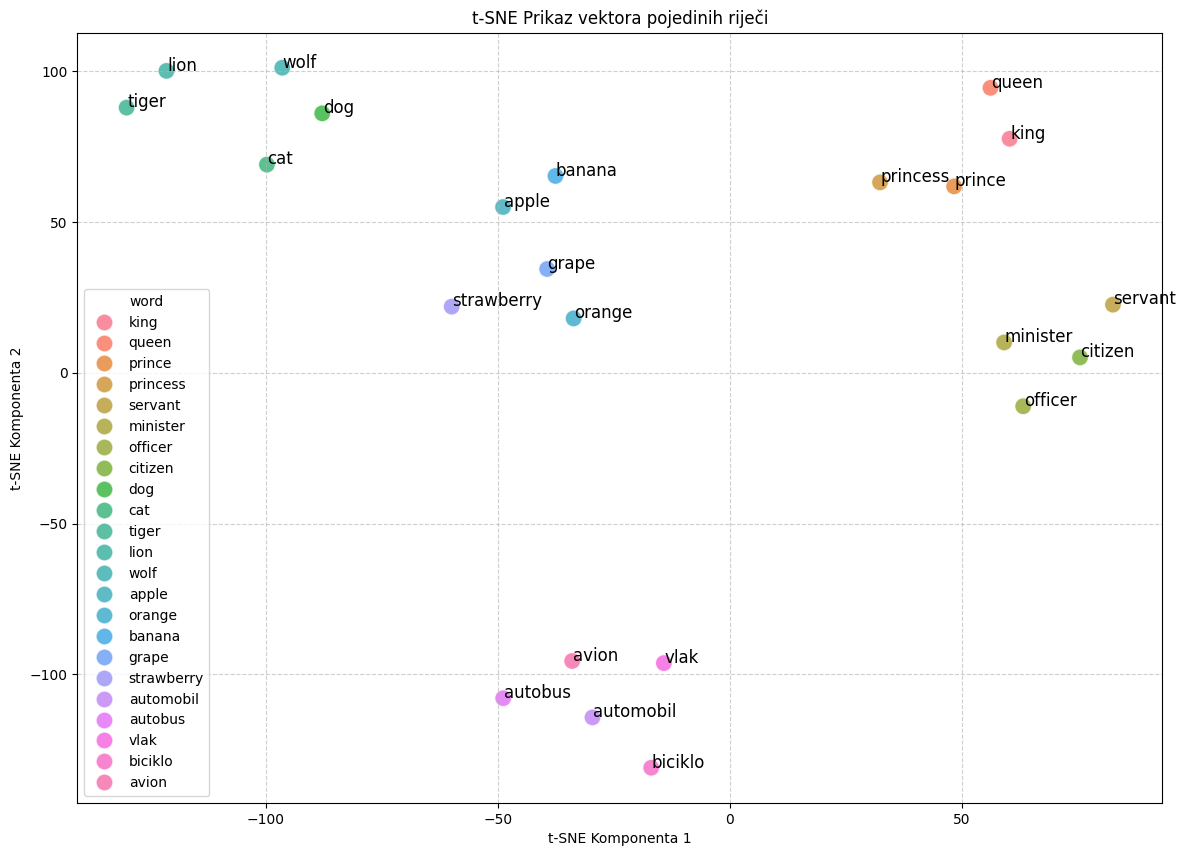

In [ ]:
tsne_words = TSNE(n_components=2, random_state=42, perplexity=min(5, len(example_words) - 1))
reduced_word_embeddings = tsne_words.fit_transform(word_embeddings)

df_tsne_words = pd.DataFrame({
    'x': reduced_word_embeddings[:, 0],
    'y': reduced_word_embeddings[:, 1],
    'word': example_words
})

plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='x', y='y',
    hue='word',
    data=df_tsne_words,
    legend='full',
    alpha=0.8,
    s=150
)

for i, word in enumerate(example_words):
    plt.text(df_tsne_words['x'][i] + 0.1, df_tsne_words['y'][i] + 0.1, word, fontsize=12)

plt.title('t-SNE Prikaz vektora pojedinih riječi')
plt.xlabel('t-SNE Komponenta 1')
plt.ylabel('t-SNE Komponenta 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5. Učitavanje podataka i indeksiranje

Učitavamo testna pitanja/odgovore iz JSON datoteke (za evaluaciju) i pravne dokumente iz mape na Google Driveu. Dokumenti se parsiraju, dijele na odlomke i indeksiraju u FAISS vektorsku bazu za kasnije pretraživanje. Napomena: Q&A parovi se **ne** dodaju u RAG bazu — koriste se isključivo za testiranje.

### Učitavanje pitanja i odgovora iz JSON datoteke

In [ ]:
try:
    with open('/content/drive/My Drive/diplomskiRad/pitanja_odgovori.json', 'r', encoding='utf-8') as f:
        qa_data = json.load(f)

    print(f"✓ Učitano {qa_data['metadata']['ukupno_pitanja']} pitanja i odgovora.")
    print(f"  Struktura:")
    for kategorija, info in qa_data['metadata']['struktura'].items():
        print(f"    - {kategorija}: {info['broj']} ({info['postotak']})")
except FileNotFoundError:
    print('Datoteka pitanja_odgovori.json nije pronađena na navedenoj putanji.')
    qa_data = None
except json.JSONDecodeError:
    print('Greška pri parsiranju JSON datoteke. Provjerite je li format ispravan.')
    qa_data = None

✓ Učitano 31 pitanja i odgovora.
  Struktura:
    - kompleksna_vise_dokumenata: 4 (12.9%)
    - kompleksna_jedan_dokument: 4 (12.9%)
    - jednostavna: 23 (74.2%)


### Inicijalizacija FAISS indeksa

FAISS (Facebook AI Similarity Search) je biblioteka za efikasno pretraživanje sličnih vektora. Koristimo `IndexFlatIP` (inner product) s L2 normaliziranim vektorima, što efektivno daje **cosine similarity** — optimalniju metriku za semantičko pretraživanje pravnih tekstova u usporedbi s L2 distancom.

In [ ]:
corpus_texts = []
corpus_metadata = []

embedding_dim = embed_model.get_sentence_embedding_dimension()
faiss_index = faiss.IndexFlatIP(embedding_dim)

/tmp/ipykernel_3332/1185578560.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = embed_model.get_sentence_embedding_dimension()


### Funkcija za dodavanje dokumenata u korpus

Ova funkcija prima tekstove, vektorizira ih pomoću embedding modela s prefiksom `"passage: "` (potrebnim za e5 model), primjenjuje L2 normalizaciju (potrebnu za cosine similarity s IndexFlatIP) i dodaje u FAISS indeks za pretraživanje.

In [ ]:
def add_documents_to_corpus(texts, metadatas=None):
    global corpus_texts, corpus_metadata, faiss_index

    if metadatas is None:
        metadatas = [None] * len(texts)

    prefixed_texts = ["passage: " + t for t in texts]
    embeddings = embed_model.encode(prefixed_texts, convert_to_numpy=True, show_progress_bar=False)

    faiss.normalize_L2(embeddings)

    corpus_texts.extend(texts)
    corpus_metadata.extend(metadatas)

    faiss_index.add(embeddings)

    print(f"Dodano {len(texts)} dokumenata u RAG korpus. Ukupno: {len(corpus_texts)}")

### Funkcije za ekstrakciju teksta i chunkanje po člancima

Pomoćne funkcije za čitanje teksta iz .docx i .pdf formata, te strukturirano chunkanje po člancima zakona. Umjesto naivnog dijeljenja na fiksne blokove od 800 znakova, tekst se dijeli prema strukturi pravnog dokumenta (`Članak X.`), čime se osigurava da svaki chunk sadrži cjelovit pravni kontekst. Dokumenti koji nemaju strukturu članaka koriste fallback chunking s overlapom.

In [ ]:
def extract_text_from_docx(file_path):
    try:
        doc = Document(file_path)
        text = '\n'.join([para.text for para in doc.paragraphs])
        return text
    except Exception as e:
        print(f"Greška pri čitanju .docx: {e}")
        return None

def extract_text_from_pdf(file_path):
    try:
        text = ""
        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
        return text
    except Exception as e:
        print(f"Greška pri čitanju PDF-a: {e}")
        return None

def chunk_by_articles(text, doc_name, max_chunk=1200, min_chunk_len=50):
    article_pattern = r'(Članak\s+\d+[a-z]?\.)'
    parts = re.split(article_pattern, text)

    if len(parts) <= 1:
        return chunk_text_with_overlap(text, chunk_size=800, overlap=200, min_chunk_len=min_chunk_len)

    chunks = []

    preamble = parts[0].strip()
    if len(preamble) >= min_chunk_len:
        if len(preamble) <= max_chunk:
            chunks.append(f"[{doc_name}] {preamble}")
        else:
            preamble_chunks = chunk_text_with_overlap(preamble, chunk_size=800, overlap=200, min_chunk_len=min_chunk_len)
            chunks.extend([f"[{doc_name}] {pc}" for pc in preamble_chunks])

    for i in range(1, len(parts), 2):
        header = parts[i].strip()
        body = parts[i + 1].strip() if i + 1 < len(parts) else ""
        article_text = f"{header}\n{body}"

        if len(article_text) + len(doc_name) + 3 <= max_chunk:
            if len(article_text) >= min_chunk_len:
                chunks.append(f"[{doc_name}] {article_text}")
        else:
            sub_parts = re.split(r'\n(?=\(\d+\)|\–\s|–\s)', body)
            current_sub = f"{header}"

            for sp in sub_parts:
                sp = sp.strip()
                if not sp:
                    continue
                if len(current_sub) + len(sp) + len(doc_name) + 4 <= max_chunk:
                    current_sub += "\n" + sp
                else:
                    if len(current_sub) >= min_chunk_len:
                        chunks.append(f"[{doc_name}] {current_sub}")
                    current_sub = f"{header} (nastavak)\n{sp}"

            if len(current_sub) >= min_chunk_len:
                chunks.append(f"[{doc_name}] {current_sub}")

    return chunks

def chunk_text_with_overlap(text, chunk_size=800, overlap=200, min_chunk_len=50):
    paragraphs = text.split('\n\n')
    paragraphs = [p.strip() for p in paragraphs if p.strip()]

    split_paragraphs = []
    for para in paragraphs:
        if len(para) <= chunk_size:
            split_paragraphs.append(para)
        else:
            start = 0
            while start < len(para):
                end = start + chunk_size
                if end >= len(para):
                    split_paragraphs.append(para[start:])
                    break
                space_idx = para.rfind(' ', start, end)
                if space_idx > start:
                    split_paragraphs.append(para[start:space_idx])
                    start = space_idx + 1
                else:
                    split_paragraphs.append(para[start:end])
                    start = end

    chunks = []
    current_chunk = ""

    for para in split_paragraphs:
        if len(current_chunk) + len(para) + 2 <= chunk_size:
            current_chunk = current_chunk + "\n\n" + para if current_chunk else para
        else:
            if len(current_chunk) >= min_chunk_len:
                chunks.append(current_chunk.strip())
            if overlap > 0 and current_chunk:
                overlap_text = current_chunk[-overlap:]
                space_idx = overlap_text.find(' ')
                if space_idx != -1:
                    overlap_text = overlap_text[space_idx + 1:]
                current_chunk = overlap_text + "\n\n" + para
            else:
                current_chunk = para

    if current_chunk and len(current_chunk.strip()) >= min_chunk_len:
        chunks.append(current_chunk.strip())

    return chunks

def detect_document_hierarchy(filename):
    filename_lower = filename.lower()
    if 'ustav' in filename_lower:
        return {"razina": 1, "tip_propisa": "Ustav"}
    elif 'zakon' in filename_lower:
        return {"razina": 2, "tip_propisa": "Zakon"}
    elif 'pravilnik' in filename_lower:
        return {"razina": 3, "tip_propisa": "Pravilnik"}
    else:
        return {"razina": 4, "tip_propisa": "Ostalo"}

def get_document_display_name(filename):
    name = os.path.splitext(filename)[0]
    name = name.replace('_', ' ')
    return name

### Učitavanje dokumenata iz mape i indeksiranje u korpus

Iteriramo kroz sve datoteke u mapi, ekstrahiramo tekst, dijelimo ga na chunkove prema strukturi članaka (`Članak X.`) i dodajemo u FAISS indeks. Svaki chunk sadrži prefiks s imenom dokumenta za bolji kontekst pri retrievalu.

In [ ]:
docs_dir = '/content/drive/My Drive/diplomskiRad/Dokumenti'

if os.path.exists(docs_dir):
    print(f"Učitavam dokumente iz mape: '{docs_dir}'...\n")

    for file in os.listdir(docs_dir):
        file_path = os.path.join(docs_dir, file)
        text = None

        try:
            if file.endswith('.txt'):
                with open(file_path, 'r', encoding='utf-8') as f:
                    text = f.read()
                print(f"✓ .txt: {file}")
            elif file.endswith('.docx'):
                text = extract_text_from_docx(file_path)
                if text:
                    print(f"✓ .docx: {file}")
            elif file.endswith('.doc'):
                print(f"⚠ .doc: {file} (zahtijeva LibreOffice ili specifičnu biblioteku)")
            elif file.endswith('.pdf'):
                text = extract_text_from_pdf(file_path)
                if text:
                    print(f"✓ PDF: {file}")
            else:
                print(f"⊘ Nepoznat format: {file}")

            if text:
                hierarchy = detect_document_hierarchy(file)
                doc_name = get_document_display_name(file)

                chunks = chunk_by_articles(text, doc_name, max_chunk=1200, min_chunk_len=50)

                if chunks:
                    metadatas = [{
                        "file": file,
                        "type": file.split('.')[-1],
                        "razina": hierarchy["razina"],
                        "tip_propisa": hierarchy["tip_propisa"]
                    }] * len(chunks)

                    add_documents_to_corpus(chunks, metadatas)
                    print(f"  └─ Dodano {len(chunks)} chunkova (razina: {hierarchy['tip_propisa']})\n")
        except Exception as e:
            print(f"✗ Greška pri obradi {file}: {e}\n")
else:
    print(f"Mapa '{docs_dir}' nije pronađena!")
    print(f"Dostupne stavke: {os.listdir('.')}")

Učitavam dokumente iz mape: '/content/drive/My Drive/diplomskiRad/Dokumenti'...



✓ PDF: Pravilnik o temeljnom vojnom osposobljavanju.pdf
Dodano 24 dokumenata u RAG korpus. Ukupno: 24
  └─ Dodano 24 chunkova (razina: Pravilnik)

✓ .docx: Ustav Republike Hrvatske 2018.docx
Dodano 173 dokumenata u RAG korpus. Ukupno: 197
  └─ Dodano 173 chunkova (razina: Ustav)

✓ .docx: Zakon_o_obrani_2025.docx
Dodano 251 dokumenata u RAG korpus. Ukupno: 448
  └─ Dodano 251 chunkova (razina: Zakon)

✓ .docx: Zakon_o_sluzbi_u_Oruzanim_snagama_Republike_Hrvatske_2025.docx
Dodano 373 dokumenata u RAG korpus. Ukupno: 821
  └─ Dodano 373 chunkova (razina: Zakon)

⊘ Nepoznat format: Pravilnik o temeljnom vojnom osposobljavanju.html


### Prikaz statistike RAG korpusa

Nakon učitavanja svih dokumenata ispisujemo ukupan broj tekstualnih chunkova u korpusu i FAISS indeksu, te prikazujemo primjere prvih učitanih chunkova kako bismo potvrdili ispravnost procesa učitavanja i indeksiranja.

In [ ]:
print(f"\nStatistika RAG korporusa:")
print(f" Ukupno učitano {len(corpus_texts)} dokumenata za RAG.")
print(f" FAISS index sadrži {faiss_index.ntotal} dokumenata.")

if corpus_texts:
    print("\nPrimjeri učitanih dokumenata (prva 3):")
    for i, doc in enumerate(corpus_texts[:3], 1):
        preview = doc[:150] + "..." if len(doc) > 150 else doc
        print(f"\n   [{i}] {preview}")
else:
    print("\nNema učitanih dokumenata! Provjerite mapu 'Dokumenti'.")


Statistika RAG korporusa:
 Ukupno učitano 821 dokumenata za RAG.
 FAISS index sadrži 821 dokumenata.

Primjeri učitanih dokumenata (prva 3):

   [1] [Pravilnik o temeljnom vojnom osposobljavanju] NN 155/2025 (23.12.2025.), Pravilnik o temeljnom vojnom osposobljavanju
MINISTARSTVO OBRANE
2328
Na tem...

   [2] [Pravilnik o temeljnom vojnom osposobljavanju] Članak 1.
(1) Ovim se Pravilnikom propisuje postupak prijave i evidencije kandidata i upućivanje kandid...

   [3] [Pravilnik o temeljnom vojnom osposobljavanju] Članak 2.
Pojmovi koji se koriste u ovom Pravilniku imaju sljedeće značenje:
– kandidat je novak i osob...


## 6. RAG sustav (Retrieval-Augmented Generation)

RAG je tehnika koja poboljšava generaciju teksta tako što najprije dohvaća relevantne dokumente iz baze znanja, a zatim ih koristi kao kontekst za LLM model. Ovo omogućuje modelu da daje točnije odgovore temeljene na stvarnim dokumentima, umjesto da se oslanja isključivo na znanje stečeno tijekom treniranja.

### Funkcija za dohvaćanje relevantnih odlomaka

Prima korisnikov upit, vektorizira ga, normalizira i pretražuje FAISS indeks za pronalaženje najsličnijih odlomaka iz korpusa dokumenata. Koristi `top_k=5` za šire pokrivanje pravnih tekstova i `score_threshold=0.4` za filtriranje irelevantnih rezultata. Re-ranking primjenjuje umjeren hijerarhijski boost (0.02 po razini) kako bi viši pravni propisi imali blagu prednost bez dominacije nad semantičkom relevantnošću.

### Funkcija za generiranje odgovora

Glavna funkcija sustava koja objedinjuje RAG retrieval i generaciju teksta. Ako je RAG uključen, dohvaća relevantne odlomke iz FAISS indeksa i ubacuje ih u sistemsku poruku kao kontekst. Automatski skraćuje kontekst ako broj tokena prelazi ograničenje modela, a u postprocesiranju uklanja nepotpune odgovore koji ne završavaju interpunkcijskim znakom.

### Definicija sistemske poruke (System Prompt)

Sistemska poruka postavlja ulogu i način ponašanja modela. Model je definiran kao pravni stručnjak za zakonodavstvo Republike Hrvatske s naglaskom na Zakon o obrani i Zakon o službi u Oružanim snagama. Poruka sadrži i kritične upute za sprječavanje generiranja odgovora na krivom jeziku ili pismu — problem koji se javlja kod višejezičnih modela poput EuroLLM-a.

### Putanja CSV datoteke i Vanilla chat funkcija

Definiramo putanju CSV datoteke za pohranu svih rezultata testiranja, te funkciju `vanilla_chat` koja šalje pitanje modelu bez RAG konteksta. Ova funkcija koristi nisku temperaturu (0.3) za konzistentnije odgovore i eksplicitno traži odgovor na hrvatskom jeziku latinicom.

In [ ]:
def retrieve_relevant_passages(query, top_k=5, score_threshold=0.4, rerank_top_k=None):
    if len(corpus_texts) == 0:
        return []

    fetch_k = min(top_k * 2, len(corpus_texts))

    query_embedding = embed_model.encode(["query: " + query], convert_to_numpy=True, show_progress_bar=False)

    faiss.normalize_L2(query_embedding)

    D, I = faiss_index.search(query_embedding, fetch_k)

    candidates = []
    for score, idx in zip(D[0], I[0]):
        if idx == -1:
            continue
        if score < score_threshold:
            continue
        candidates.append({
            "text": corpus_texts[idx],
            "score": float(score),
            "metadata": corpus_metadata[idx]
        })

    for c in candidates:
        if c["metadata"] is not None and "razina" in c["metadata"]:
            razina = c["metadata"]["razina"]
            hierarchy_boost = max(0, (4 - razina)) * 0.02
            c["score"] = c["score"] + hierarchy_boost

    candidates.sort(key=lambda x: x["score"], reverse=True)

    unique_results = []
    for c in candidates:
        c_words = set(c["text"].split())
        is_duplicate = False
        for existing in unique_results:
            existing_words = set(existing["text"].split())
            intersection = len(c_words & existing_words)
            union = len(c_words | existing_words)
            if union > 0 and intersection / union > 0.85:
                is_duplicate = True
                break
        if not is_duplicate:
            unique_results.append(c)

    final_k = rerank_top_k if rerank_top_k else top_k
    return unique_results[:final_k]

In [ ]:
def generate_response(
    messages,
    max_new_tokens=512,
    temperature=0.5,
    do_sample=True,
    use_rag=False,
    rag_top_k=3
):
    final_messages = list(messages)

    if use_rag:
        user_query = ""
        for m in reversed(final_messages):
            if m["role"] == "user":
                user_query = m["content"]
                break

        if user_query:
            retrieved = retrieve_relevant_passages(user_query, top_k=rag_top_k)

            if len(retrieved) > 0:
                context_parts = []
                for i, r in enumerate(retrieved, start=1):
                    meta_str = ""
                    if r["metadata"] is not None and "file" in r["metadata"]:
                        meta_str = f" (izvor: {r['metadata']['file']})"
                    context_parts.append(f"[{i}] {r['text']}{meta_str}")

                context_text = "\n\n".join(context_parts)

                if final_messages and final_messages[0]["role"] == "system":
                    final_messages[0]["content"] = (
                        final_messages[0]["content"] + "\n\n"
                        "Kontekst za odgovor:\n"
                        f"{context_text}"
                    )
                else:
                    final_messages.insert(0, {
                        "role": "system",
                        "content": SYSTEM_PROMPT + f"\n\nKontekst za odgovor:\n{context_text}",
                    })

    model_max_length = getattr(pipe.tokenizer, 'model_max_length', 4096)
    if model_max_length > 100000:
        model_max_length = 4096

    input_text = pipe.tokenizer.apply_chat_template(final_messages, tokenize=False)
    input_token_count = len(pipe.tokenizer.encode(input_text))
    max_allowed_input = model_max_length - max_new_tokens

    if input_token_count > max_allowed_input:
        print(f"Upozorenje: input ({input_token_count} tokena) prelazi limit ({max_allowed_input}). Skraćujem kontekst.")
        if use_rag and final_messages and final_messages[0]["role"] == "system":
            system_content = final_messages[0]["content"]
            while input_token_count > max_allowed_input and "\n\n[" in system_content:
                last_chunk_start = system_content.rfind("\n\n[")
                system_content = system_content[:last_chunk_start]
                final_messages[0]["content"] = system_content
                input_text = pipe.tokenizer.apply_chat_template(final_messages, tokenize=False)
                input_token_count = len(pipe.tokenizer.encode(input_text))
            print(f"  Skraćeno na {input_token_count} tokena.")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gen_config = deepcopy(pipe.model.generation_config)
    gen_config.max_new_tokens = max_new_tokens
    gen_config.temperature = temperature
    gen_config.do_sample = do_sample
    gen_config.repetition_penalty = 1.3

    vrijeme_upita = time.time()

    response = pipe(
        final_messages,
        generation_config=gen_config,
    )

    answer = ""
    for message in response[0]['generated_text']:
        if message['role'] == 'assistant':
            answer = message['content']
            break

    stripped_answer = answer.strip()
    if not re.search(r'[.!?]$', stripped_answer) and len(stripped_answer.split()) > 5:
        last_punctuation_index = -1
        for i in range(len(stripped_answer) - 1, -1, -1):
            if stripped_answer[i] in ['.', '?', '!']:
                last_punctuation_index = i
                break

        if last_punctuation_index != -1:
            answer = stripped_answer[:last_punctuation_index + 1]
        else:
            words = stripped_answer.split()
            if len(words) > 1:
                answer = ' '.join(words[:-1]) + '...'
            elif words:
                answer = words[0]
            else:
                answer = ''
    else:
        answer = stripped_answer

    vrijeme_odgovora = time.time()
    ukupno_vrijeme = vrijeme_odgovora - vrijeme_upita

    print("Generirani odgovor:")
    print(answer)
    print(f"Ukupno vrijeme za odgovor: {ukupno_vrijeme:.2f} sekundi")

    return answer, ukupno_vrijeme

In [ ]:
SYSTEM_PROMPT = (
"Ti si pravni stručnjak specijaliziran za zakonodavstvo Republike Hrvatske, posebno za Zakon o obrani, Zakon o službi u Oružanim snagama RH i pripadajuće pravilnike."
"\n\nPravila odgovaranja:"
"\n1. Jezik odgovora: hrvatski, latinica."
"\n2. Navedi konkretne članke zakona, brojčane vrijednosti i nadležna tijela."
"\n3. Ako je dostupan kontekst, koristi SAMO informacije iz njega."
"\n4. Ako kontekst ne sadržava odgovor, odgovori na temelju općeg znanja i dodaj: 'Napomena: ova informacija nije pronađena u dostupnim dokumentima."
"\n5. Odgovor neka bude koncizan i strukturiran — bez nepotrebnih uvoda."
)

In [ ]:
csv_path = '/content/drive/My Drive/diplomskiRad/rezultati.csv'

def vanilla_chat(user_question):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"{user_question}\n\nOdgovori NA HRVATSKOM JEZIKU koristeći LATINICU."}
    ]
    return generate_response(messages, max_new_tokens=256, temperature=0.3, do_sample=True)

## 7. Testiranje - Vanilla pristup (bez RAG-a)

Vanilla pristup koristi LLM model bez dodatne baze znanja. Model se oslanja isključivo na znanje stečeno tijekom treniranja. Ovo služi kao bazna linija za usporedbu s RAG pristupom.

### Testiranje Vanilla pristupa - sva pitanja

Prolazimo kroz sva pitanja iz JSON datoteke, generiramo odgovore bez RAG-a i spremamo rezultate u CSV datoteku.

In [ ]:
if qa_data is None:
    print("QA datoteka nije ucitana.")
else:
    all_questions = []
    all_categories = []
    for key, value in qa_data.items():
        if key != 'metadata' and isinstance(value, list):
            for item in value:
                all_questions.append(item)
                all_categories.append(key)

    vanilla_rezultati = []

    for i, (qa_item, kategorija) in enumerate(zip(all_questions, all_categories)):
        user_question = qa_item.get('pitanje', qa_item.get('question', ''))
        ocekivani = qa_item.get('odgovor', qa_item.get('answer', ''))

        print(f"\n{'='*80}")
        print(f"Pitanje {i + 1}/{len(all_questions)}: {user_question}")
        print(f"Kategorija: {kategorija}")
        print(f"{'='*80}")

        answer, vrijeme = vanilla_chat(user_question)

        vanilla_rezultati.append({
            'rbr': i + 1,
            'kategorija': kategorija,
            'pitanje': user_question,
            'ocekivani_odgovor': ocekivani,
            'vanilla_odgovor': answer,
            'vanilla_vrijeme_sekunde': round(vrijeme, 2)
        })

    df_rezultati = pd.DataFrame(vanilla_rezultati)
    df_rezultati.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f"\n{'='*80}")
    print(f"Vanilla rezultati spremljeni u: {csv_path}")
    print(f"Ukupno obradeno pitanja: {len(vanilla_rezultati)}")
    print(f"Prosjecno vrijeme po pitanju: {df_rezultati['vanilla_vrijeme_sekunde'].mean():.2f} sekundi")

Setting `pad_token_id` to `eos_token_id`:4 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Pitanje 1/31: Opišite cjelokupnu proceduru transformacije novaka u razvrstanog pričuvnika kroz sve pravne akte koji reguliraju taj proces.
Kategorija: kompleksna_pitanja_vise_dokumenata


Setting `pad_token_id` to `eos_token_id`:4 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generirani odgovor:
Transformacija vojnog obveznika u rezervistu odvija se prema sljedećim koracima koje određuju relevantni zakoni:
- Prvo, nakon završetka osnovnoga ili specijalističkog osposobljavanja (Zakon o službi u Oružanim snagama), vojnik postaje pripadnikom pričuve (Članak 76., stavka 8.).
- Nakon toga, ako ispunjava uvjete utvrđene Pravilnikom o postupku prijave i registracije za uključivanje u sastav pričuve (NN br. 90/12.), prijavljuje se kao kandidat za uvrštavanje u sastav pričuve (Članak 77., stavka 1).
- U slučaju da ispuni sva potrebna predviđena mjerila navedenih u istom Pravilniku, stječe status rezervista (Članak 77., stavka 2).
- Ovaj proces detaljno su uređeni Zakonom o službi u Oružanim snagama te Pravilnikom o postupku prijave i registracije za uključivanje u sastav pričuve objavljenim pod NN br. 90/12.
Ukupno vrijeme za odgovor: 25.66 sekundi

Pitanje 2/31: Hijerarhija odlučivanja o uporabi Oružanih snaga RH razlikuje šest situacija ovisno o razini ugroze. Rat

Setting `pad_token_id` to `eos_token_id`:4 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Generirani odgovor:
Minimalno trajanje godišnjeg odmora za djelatnu vojsku osobu određeno je Pravilnikom o pravu na godišnje slobodno vrijeme (Glasnik Uprave RS 67/09), a točnije prema Članku 8., stavak 1.: "Djelatnici imaju pravo na najmanje dvadeset pet dana radnog vremena tijekom kalendara godine." Dakle, minimumu četiri tjedna ili četrdeset radnih sati godišnjom mjeri. Točno razdoblje se može razlikovati ovisno o pojedinačnim slučajevima i određenim uvjetima rada. Za detaljnija pitanja preporučujem da provjerite relevantne dokumente ili kontaktirate nadležna tijela kao što su Ministarstvo branitelja ili Vojska Republike Hrvatske jer oni mogu pružiti specifične smjernice koje bi bile primjenjive samo na vaše stanje. Napomena: Ova informcija nije pronađena u dostupnim dokumentima. Međutim, ovo vam daje osnovu kako razumjeti opću definiciju.
Ukupno vrijeme za odgovor: 20.81 sekundi

Pitanje 29/31: Koliko dana plaćenog dopusta pripada djelatnoj vojnoj osobi u slučaju rođenja djeteta?
K

Setting `pad_token_id` to `eos_token_id`:4 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generirani odgovor:
Djelatnom vojnoj osobu pravo na 60 radnih dana plaćene dopuste u slučaju rođenja djeteta. Ovo se određuje prema Pravilniku o pravu na plaću i drugim materijalnim koristima ratnika (ratnica) te njihovim obiteljskim obveznicima koji su uključeni ili sudjeluju u obrambenoj aktivnosti, donesenom odlukom Vlade Republike Hrvatske od strane Ministarstva branitelja. Napomena: Ova informacija nije pronađena u dostupnim dokumentima. Međutim, ovo bi trebao biti standardni iznos navedeni u relevantnim propisima. U slučaju da postoje specifične okolnosti koje utječu na ovaj iznos, kao što su dodatak za dvoje djece ili više, to će vjerojatno utjecati na ukupnu duljinu dopusta. Za detaljnije informacije preporučujem konzultiranje najnovijih propisa ili izravno kontaktirati nadležno tijelo.
Ukupno vrijeme za odgovor: 18.39 sekundi

Pitanje 30/31: Koliko dana plaćenog dopusta pripada djelatnoj vojnoj osobi u slučaju zaključenja braka?
Kategorija: jednostavna_pitanja


Setting `pad_token_id` to `eos_token_id`:4 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generirani odgovor:
Dužnosnici koji su imalo veći utjecaj imaju pravo na 70% ukupnog iznosa plaćene odmore koje se isplaćuju tijekom godine. U slučaju zaključenja braka, dužnosnik ima pravo na dodatnu plaćenu odmoru koja će biti jednaka polovici prosječne mjesečne naknade koju prima kao službenik državne uprave. To znači da ako zaposlenici dobiju godišnju mjeru plaća (GMP) od 6 mjeseci, a njihov prosjek GMP-a iznosi 80%, onda bi dobili ukupno 9 mjeseci plaćena odmora. Međutim, točan broj dana plaćenih odmora nakon vjenčanje ovisit će o pojedinačnim okolnostima svakoga slučaja i može varirati ovisno o različitim čimbenicima poput specifičnih pravila rada i politike organizacije kojoj osoba radi ili drugih relevantnih propisa. Za detaljnije informacije preporučujem konzultiranje s vodstvom vaše tvrtke ili posjeta web stranicama Ministarstva unutarnjih poslova gdje možete pronaći više informacija o ovim pitanjima uključujući primjere kako izračunati točno količinu prava na plaćeni dopust 

## 8. Testiranje - RAG pristup

RAG pristup najprije pretražuje bazu pravnih dokumenata za relevantne odlomke, a zatim ih koristi kao kontekst pri generiranju odgovora. Očekujemo točnije i informiranije odgovore u usporedbi s Vanilla pristupom.

### RAG chat funkcija

Funkcija za postavljanje pitanja modelu s RAG-om. Dohvaćaju se relevantni odlomci iz baze dokumenata koji se zatim dodaju kao kontekst u sistemsku poruku.

In [ ]:
def rag_chat(user_question):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"{user_question}\n\nOdgovori NA HRVATSKOM JEZIKU koristeći LATINICU."}
    ]
    return generate_response(messages, max_new_tokens=256, temperature=0.3, do_sample=True, use_rag=True, rag_top_k=5)

### Testiranje RAG pristupa - sva pitanja

Prolazimo kroz sva pitanja iz JSON datoteke, generiramo odgovore s RAG-om i rezultate nadopunjujemo u postojece redove CSV datoteke kao nove stupce.

In [ ]:
if qa_data is None:
    print("QA datoteka nije ucitana.")
else:
    df_rezultati = pd.read_csv(csv_path, encoding='utf-8-sig')

    all_questions = []
    all_categories = []
    for key, value in qa_data.items():
        if key != 'metadata' and isinstance(value, list):
            for item in value:
                all_questions.append(item)
                all_categories.append(key)

    rag_odgovori = []
    rag_vremena = []

    for i, (qa_item, kategorija) in enumerate(zip(all_questions, all_categories)):
        user_question = qa_item.get('pitanje', qa_item.get('question', ''))

        print(f"\n{'='*80}")
        print(f"Pitanje {i + 1}/{len(all_questions)}: {user_question}")
        print(f"Kategorija: {kategorija}")
        print(f"{'='*80}")

        answer, vrijeme = rag_chat(user_question)

        rag_odgovori.append(answer)
        rag_vremena.append(round(vrijeme, 2))

    df_rezultati['rag_odgovor'] = rag_odgovori
    df_rezultati['rag_vrijeme_sekunde'] = rag_vremena
    df_rezultati.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f"\n{'='*80}")
    print(f"RAG rezultati nadopunjeni u: {csv_path}")
    print(f"Ukupno obradeno pitanja: {len(rag_odgovori)}")
    print(f"Prosjecno vrijeme po pitanju: {sum(rag_vremena)/len(rag_vremena):.2f} sekundi")

Setting `pad_token_id` to `eos_token_id`:4 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Pitanje 1/31: Opišite cjelokupnu proceduru transformacije novaka u razvrstanog pričuvnika kroz sve pravne akte koji reguliraju taj proces.
Kategorija: kompleksna_pitanja_vise_dokumenata


Setting `pad_token_id` to `eos_token_id`:4 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generirani odgovor:
Celovita procedura pretvaranja novaka u razvrstavljenu pričuvu prolazi kroz nekoliko koraka kako to propisuju zakoni i Pravilnici Republike Hrvatske. Ovaj postupak uključuje sljedeće faze:

Prvi korak započinje kada novi pristupnik napuni 18 godina i treba mu se registrirati diplomacijskom misiji ili konzulatu Republike Hrvatske ako živi izvan zemlje. Ovo je navedeno u članku 21. Zakona o obranji.

Drugi korak je procjena sposobnosti za vojsku koja se provodi prema člnaku 25.(1). Nakon što ispune određenu dob, novoosnovanci moraju potvrditi svoju sposobnost da rade vojne zadatke.

Treći korak je mogućnost da novi pristupnik postane nerazdvojivim pričunikom ako još nema određene vojne specijalne vještine. To je opisano u članku 25.(2)(k).

Četvrtti korak omogućuje ministarstvu obrany sklapanje ugovora između novih pristupnika koji već imaju iskustvo vojske i onih koji žele nastaviti svoje vojne aktivnosti.
Ukupno vrijeme za odgovor: 25.52 sekundi

Pitanje 2/31: Hijer

Setting `pad_token_id` to `eos_token_id`:4 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Generirani odgovor:
Minimalno trajanje minimuma godišnjega odmora djelatne vojne osobe određeno je člancima Zakona o službi u Oružanim snagama Republike Hrvatske 2025., ali točan odgovor zahtijeva detaljniju analizu relevantnih pravila. Međutim, možemo zaključiti kako je minimalno trajanje jednako četiri tjedna. Točnije podatke potražite izravno iz primarnog dokumenata jer ovaj tekst samo kratko prikazuje neke aspekte tog pitanja. За подробности и точни дати погледнете в първоначалния документ директно защото този текст само кратко описва някои аспекти на въпроса.  За да получите най-точната информация за минималната продължителност отпусков период военнослужещия, моля вижте източника на закона директно тъй като тази статия дава кратък преглед на някои аспекти на темата.
Ukupno vrijeme za odgovor: 25.38 sekundi

Pitanje 29/31: Koliko dana plaćenog dopusta pripada djelatnoj vojnoj osobi u slučaju rođenja djeteta?
Kategorija: jednostavna_pitanja


Setting `pad_token_id` to `eos_token_id`:4 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generirani odgovor:
Prema zakonu navedenom u tekstu, pripadniku oružanih snaga koji postane otac djetetu pripada pravo na plaćeni dopust u iznosu od **sedam** radnih dana.  To je točno prema člnaku 159., podtočki a), prvog dijela pravila "Često pitani pitanja" ovog teksta.
Ukupno vrijeme za odgovor: 7.45 sekundi

Pitanje 30/31: Koliko dana plaćenog dopusta pripada djelatnoj vojnoj osobi u slučaju zaključenja braka?
Kategorija: jednostavna_pitanja


Setting `pad_token_id` to `eos_token_id`:4 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generirani odgovor:
Prema zakonu navedenom u tekstu, djelatnoj vojni osebi pripada pravo na plaćeni dopust do ukupno **petnaestak** radnih dana u kalendarskom roku u slučaju zaključaja braka. Točnije, to uključuje sedam radnih dana za taj događaj.  

Izraz "prethodni" znači da se ti dani računaju prije nego što počinje novi kalendarski rok. Na primjer, ako ste vjenčani krajem siječnja, prava ćete imati tijekom cijelog veljače i ožujka.
Ukupno vrijeme za odgovor: 11.41 sekundi

Pitanje 31/31: Što je vojna iskaznica i tko ju izdaje?
Kategorija: jednostavna_pitanja
Generirani odgovor:
Vojna iskaznica je javna isprava koja potvrđuje identitet osobe dok izvodi vojnu obvezu. Izdaje ih nadležni teritorijalni ured za obrambene poslove koji vojsku drži kao registrirani subjekt. To znači da svaki pojedinac mora zadržati svoju vojnu iskaznicu kako bi mogao dokazivati svoje pravo kada sudjeluju u vojsci. Pravilnik određuje detalje o obliku i sadržaju ove isprave koju ministar obrane propisao.  

I